### Importação das bibliotecas

Nesta célula, importamos as bibliotecas usadas na análise: manipulação de dados, operações numéricas e visualização.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Carregamento e preparação dos dados

Nesta célula, carregamos os arquivos CSV, tratamos possíveis erros de leitura para o carregamento dos DataFrames.


In [2]:
# Carregar o dataset. A codificação 'latin-1' é necessária para ler caracteres especiais presentes no arquivo.
try:
    bens = pd.read_csv("data/bem_candidato_2026_AM.csv", sep=";",
                       encoding="latin-1", decimal=",", dtype={"SQ_CANDIDATO": str}, usecols=["SQ_CANDIDATO", "DS_TIPO_BEM_CANDIDATO", "VR_BEM_CANDIDATO", "SG_UF"])
    cand = pd.read_csv("data/consulta_cand_2026_AM.csv", sep=";",
                       encoding="latin-1", dtype={"SQ_CANDIDATO": str, "NR_CANDIDATO": str}, usecols=["SQ_CANDIDATO", "NR_CANDIDATO", "DS_CARGO", "SG_PARTIDO", "DS_GENERO", "NM_URNA_CANDIDATO", "DS_GRAU_INSTRUCAO", "DS_OCUPACAO"])
    print("Datasets carregados com sucesso!")
except FileNotFoundError as e:
    print(
        f"Erro: Arquivo não encontrado. Verifique o nome e o caminho do arquivo: {e.filename}")
    # Define Dataframes como None para evitar erros nas células seguintes
    bens = None
    cand = None

Datasets carregados com sucesso!


### Dados de bens fornecido pelo Tribunal Superior Eleitoral (TSE)

Este dataframe contém informações sobre os bens declarados pelos candidatos, incluindo o valor e a descrição de cada bem, um bem por linha, e a chave primária do candidato (SQ_CANDIDATO) que possui o bem.


In [3]:
if bens is not None:
    # Visualizar 10 primeiras linhas do DataFrame
    print("\n10 primeiras linhas:")
    display(bens.head(10))

    # Verificar as dimensões do DataFrame (linhas, colunas)
    print(f"\nDimensões do DataFrame: {bens.shape}")

    # Obter um resumo técnico do DataFrame
    print("\nInformações do DataFrame:")
    bens.info()

    # Obter estatísticas descritivas das colunas numéricas
    print("\nEstatísticas Descritivas:")
    display(bens.describe().T)

    # Obter a lista de colunas do DataFrame
    print("\nColunas resultantes:")
    print(bens.columns.tolist())


10 primeiras linhas:


,SG_UF,SQ_CANDIDATO,DS_TIPO_BEM_CANDIDATO,VR_BEM_CANDIDATO
0,AM,40002531438,"Veículo automotor terrestre: caminhão, automóv...",140000.00
1,AM,40002531438,Terreno,80000.00
2,AM,40002531438,Casa,90000.00
3,AM,40002531439,Depósito bancário em conta corrente no País,1339.16
4,AM,40002531439,Depósito bancário em conta corrente no País,375.91
5,AM,40002531439,Depósito bancário em conta corrente no País,158.42
6,AM,40002531440,Embarcação,2300000.00
7,AM,40002531440,Quotas ou quinhões de capital,990000.00
8,AM,40002531440,Quotas ou quinhões de capital,70000.00
9,AM,40002531440,"Veículo automotor terrestre: caminhão, automóv...",316000.00



Dimensões do DataFrame: (1654, 4)

Informações do DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 1654 entries, 0 to 1653
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SG_UF                  1654 non-null   str    
 1   SQ_CANDIDATO           1654 non-null   str    
 2   DS_TIPO_BEM_CANDIDATO  1654 non-null   str    
 3   VR_BEM_CANDIDATO       1654 non-null   float64
dtypes: float64(1), str(3)
memory usage: 127.6 KB

Estatísticas Descritivas:


,count,mean,std,min,25%,50%,75%,max
VR_BEM_CANDIDATO,1654.0,310797.667152,2.407173e+06,0.0,10000.0,65080.5,225688.155,92004111.43



Colunas resultantes:
['SG_UF', 'SQ_CANDIDATO', 'DS_TIPO_BEM_CANDIDATO', 'VR_BEM_CANDIDATO']


### Dados de candidatos fornecido pelo Tribunal Superior Eleitoral (TSE)

Este dataframe contém informações sobre os candidatos, incluindo o número do candidato (NR_CANDIDATO), a chave primária do candidato (SQ_CANDIDATO) e outras informações relevantes para a análise.

Antes do join de dataframes foi feita a deduplicação de candidatos, para evitar que candidatos com o mesmo SQ_CANDIDATO fossem contados mais de uma vez, gerando inconsistências na análise.

- A deduplicação foi feita com base na coluna 'SQ_CANDIDATO', que é a chave primária do dataframe de candidatos.

- Caso houvesse candidatos duplicados, o primeiro registro encontrado seria mantido e os demais seriam descartados.

- Portanto, a deduplicação foi feita antes do merge para garantir que cada candidato fosse representado apenas uma vez no DataFrame final e seus bens fossem somados corretamente.


In [4]:
if cand is not None:
    # Verificar a quantidade de candidatos duplicados
    print(
        f"\nNúmero de candidatos duplicados antes: {cand.duplicated().sum()}")
    cand.drop_duplicates(subset='SQ_CANDIDATO', inplace=True)
    print(
        f"\nNúmero de candidatos duplicados depois: {cand.duplicated().sum()}")

    # Visualizar 10 primeiras linhas do DataFrame
    print("\n10 primeiras linhas:")
    display(cand.head(10))

    # Verificar as dimensões do DataFrame (linhas, colunas)
    print(f"\nDimensões do DataFrame: {cand.shape}")

    # Obter um resumo técnico do DataFrame
    print("\nInformações do DataFrame:")
    cand.info()

    # Obter estatísticas descritivas das colunas numéricas
    print("\nEstatísticas Descritivas:")
    display(cand.describe().T)

    # Obter a lista de colunas do DataFrame
    print("\nColunas resultantes:")
    print(cand.columns.tolist())


Número de candidatos duplicados antes: 0

Número de candidatos duplicados depois: 0

10 primeiras linhas:


,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_URNA_CANDIDATO,SG_PARTIDO,DS_GENERO,DS_GRAU_INSTRUCAO,DS_OCUPACAO
0,DEPUTADO ESTADUAL,40002542959,22888,ANDREA RAMOS,PL,FEMININO,SUPERIOR INCOMPLETO,AGENTE ADMINISTRATIVO
1,DEPUTADO ESTADUAL,40002542967,22002,FABRICIO MAR,PL,MASCULINO,ENSINO MÉDIO INCOMPLETO,EMPRESÁRIO
2,DEPUTADO ESTADUAL,40002542968,22333,CABO MACIEL,PL,MASCULINO,ENSINO MÉDIO COMPLETO,DEPUTADO
3,DEPUTADO ESTADUAL,40002541611,20500,NAZARE PEREIRA,PODE,FEMININO,ENSINO MÉDIO COMPLETO,APOSENTADO (EXCETO SERVIDOR PÚBLICO)
4,DEPUTADO ESTADUAL,40002541608,20234,PROFESSORA EDITH FALCÃO,PODE,FEMININO,SUPERIOR COMPLETO,PROFESSOR DE ENSINO SUPERIOR
5,DEPUTADO ESTADUAL,40002551311,18123,DANIELLE BARÉ,REDE,FEMININO,SUPERIOR COMPLETO,ADVOGADO
6,DEPUTADO ESTADUAL,40002551307,18418,ROMANO,REDE,MASCULINO,ENSINO MÉDIO COMPLETO,OUTROS
7,DEPUTADO ESTADUAL,40002542653,11111,RODRIGO SÁ,PP,MASCULINO,SUPERIOR COMPLETO,VEREADOR
8,DEPUTADO FEDERAL,40002533203,1001,ADRIANA BORGES,REPUBLICANOS,FEMININO,SUPERIOR COMPLETO,ENFERMEIRO
9,DEPUTADO FEDERAL,40002539051,1433,JOTA BRANDÃO,MISSÃO,MASCULINO,ENSINO FUNDAMENTAL COMPLETO,AGENCIADOR DE PROPAGANDA



Dimensões do DataFrame: (468, 8)

Informações do DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   DS_CARGO           468 non-null    str  
 1   SQ_CANDIDATO       468 non-null    str  
 2   NR_CANDIDATO       468 non-null    str  
 3   NM_URNA_CANDIDATO  468 non-null    str  
 4   SG_PARTIDO         468 non-null    str  
 5   DS_GENERO          468 non-null    str  
 6   DS_GRAU_INSTRUCAO  468 non-null    str  
 7   DS_OCUPACAO        468 non-null    str  
dtypes: str(8)
memory usage: 72.6 KB

Estatísticas Descritivas:


,count,unique,top,freq
DS_CARGO,468,7,DEPUTADO ESTADUAL,289
SQ_CANDIDATO,468,468,40002542959,1
NR_CANDIDATO,468,441,161,3
NM_URNA_CANDIDATO,468,468,ANDREA RAMOS,1
SG_PARTIDO,468,23,PL,39
DS_GENERO,468,2,MASCULINO,303
DS_GRAU_INSTRUCAO,468,7,SUPERIOR COMPLETO,288
DS_OCUPACAO,468,81,EMPRESÁRIO,73



Colunas resultantes:
['DS_CARGO', 'SQ_CANDIDATO', 'NR_CANDIDATO', 'NM_URNA_CANDIDATO', 'SG_PARTIDO', 'DS_GENERO', 'DS_GRAU_INSTRUCAO', 'DS_OCUPACAO']


### Operação de join entre os dataframes de candidatos e bens

Este dataframe contém informações sobre os candidatos e seus bens, incluindo o tipo de bem, o valor do bem e a chave primária do candidato (SQ_CANDIDATO) que possui o bem.


In [5]:
if bens is not None or cand is not None:
    # Executando o merge dos DataFrames bens e cand com base na coluna 'SQ_CANDIDATO'
    df = pd.merge(bens, cand, on='SQ_CANDIDATO')

    # Visualizar 10 primeiras linhas do DataFrame
    print("\n10 primeiras linhas:")
    display(df.head(10))

    # Verificar as dimensões do DataFrame (linhas, colunas)
    print(f"\nDimensões do DataFrame: {df.shape}")

    # Obter um resumo técnico do DataFrame
    print("\nInformações do DataFrame:")
    df.info()

    # Obter estatísticas descritivas das colunas numéricas
    print("\nEstatísticas Descritivas:")
    display(df.describe().T)

    # Obter a lista de colunas do DataFrame
    print("\nColunas resultantes:")
    print(df.columns.tolist())


10 primeiras linhas:


,SG_UF,SQ_CANDIDATO,DS_TIPO_BEM_CANDIDATO,VR_BEM_CANDIDATO,DS_CARGO,NR_CANDIDATO,NM_URNA_CANDIDATO,SG_PARTIDO,DS_GENERO,DS_GRAU_INSTRUCAO,DS_OCUPACAO
0,AM,40002531438,"Veículo automotor terrestre: caminhão, automóv...",140000.00,DEPUTADO FEDERAL,1513,VANDA WITOTO,MDB,FEMININO,SUPERIOR COMPLETO,PEDAGOGO
1,AM,40002531438,Terreno,80000.00,DEPUTADO FEDERAL,1513,VANDA WITOTO,MDB,FEMININO,SUPERIOR COMPLETO,PEDAGOGO
2,AM,40002531438,Casa,90000.00,DEPUTADO FEDERAL,1513,VANDA WITOTO,MDB,FEMININO,SUPERIOR COMPLETO,PEDAGOGO
3,AM,40002531439,Depósito bancário em conta corrente no País,1339.16,DEPUTADO FEDERAL,1505,DRA. AMANDA PINHEIRO,MDB,FEMININO,SUPERIOR COMPLETO,ADVOGADO
4,AM,40002531439,Depósito bancário em conta corrente no País,375.91,DEPUTADO FEDERAL,1505,DRA. AMANDA PINHEIRO,MDB,FEMININO,SUPERIOR COMPLETO,ADVOGADO
5,AM,40002531439,Depósito bancário em conta corrente no País,158.42,DEPUTADO FEDERAL,1505,DRA. AMANDA PINHEIRO,MDB,FEMININO,SUPERIOR COMPLETO,ADVOGADO
6,AM,40002531440,Embarcação,2300000.00,DEPUTADO FEDERAL,1500,JESUS ALVES,MDB,MASCULINO,SUPERIOR COMPLETO,EMPRESÁRIO
7,AM,40002531440,Quotas ou quinhões de capital,990000.00,DEPUTADO FEDERAL,1500,JESUS ALVES,MDB,MASCULINO,SUPERIOR COMPLETO,EMPRESÁRIO
8,AM,40002531440,Quotas ou quinhões de capital,70000.00,DEPUTADO FEDERAL,1500,JESUS ALVES,MDB,MASCULINO,SUPERIOR COMPLETO,EMPRESÁRIO
9,AM,40002531440,"Veículo automotor terrestre: caminhão, automóv...",316000.00,DEPUTADO FEDERAL,1500,JESUS ALVES,MDB,MASCULINO,SUPERIOR COMPLETO,EMPRESÁRIO



Dimensões do DataFrame: (1653, 11)

Informações do DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 1653 entries, 0 to 1652
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SG_UF                  1653 non-null   str    
 1   SQ_CANDIDATO           1653 non-null   str    
 2   DS_TIPO_BEM_CANDIDATO  1653 non-null   str    
 3   VR_BEM_CANDIDATO       1653 non-null   float64
 4   DS_CARGO               1653 non-null   str    
 5   NR_CANDIDATO           1653 non-null   str    
 6   NM_URNA_CANDIDATO      1653 non-null   str    
 7   SG_PARTIDO             1653 non-null   str    
 8   DS_GENERO              1653 non-null   str    
 9   DS_GRAU_INSTRUCAO      1653 non-null   str    
 10  DS_OCUPACAO            1653 non-null   str    
dtypes: float64(1), str(10)
memory usage: 346.7 KB

Estatísticas Descritivas:


,count,mean,std,min,25%,50%,75%,max
VR_BEM_CANDIDATO,1653.0,310683.207181,2.407897e+06,0.0,10000.0,65000.0,225000.0,92004111.43



Colunas resultantes:
['SG_UF', 'SQ_CANDIDATO', 'DS_TIPO_BEM_CANDIDATO', 'VR_BEM_CANDIDATO', 'DS_CARGO', 'NR_CANDIDATO', 'NM_URNA_CANDIDATO', 'SG_PARTIDO', 'DS_GENERO', 'DS_GRAU_INSTRUCAO', 'DS_OCUPACAO']


### Agregação dos valores dos bens por candidato

Essa análise tem como objetivo agregar os valores dos bens por candidato, somando o valor total dos bens e contando a quantidade de bens declarados por cada candidato. O resultado é um DataFrame que contém o SQ_CANDIDATO, o VR_TOTAL_BENS e a QTD_BENS para cada candidato sem levar em consideração o tipo de bem.


In [6]:
# Agregar o valor dos bens por candidato e identificar o tipo de bem mais frequente
def tipo_bem_mais_frequente(serie):
    frequencias = serie.dropna().mode()
    return frequencias.iat[0] if not frequencias.empty else pd.NA


bens_por_candidato = (
    bens.groupby("SQ_CANDIDATO", as_index=False)
    .agg(
        patrimonio_total=("VR_BEM_CANDIDATO", "sum"),
        qtd_bens=("VR_BEM_CANDIDATO", "size"),
        tipo_principal=(
            "DS_TIPO_BEM_CANDIDATO", tipo_bem_mais_frequente),
    )
)

# Juntar com os dados dos candidatos para manter identificação e demais variáveis
bens_por_candidato = cand.merge(
    bens_por_candidato, on="SQ_CANDIDATO", how="left")
bens_por_candidato[["patrimonio_total", "qtd_bens"]] = bens_por_candidato[[
    "patrimonio_total", "qtd_bens"]].fillna(0)
bens_por_candidato = bens_por_candidato.sort_values(
    "patrimonio_total", ascending=False)

# Visualizar 10 primeiras linhas do DataFrame
print("10 primeiras linhas do dataframe agregado:")
display(bens_por_candidato.head(10))

# Verificar as dimensões do DataFrame (linhas, colunas)
print(f"\nDimensões do DataFrame: {bens_por_candidato.shape}")

# Obter um resumo técnico do DataFrame
print("\nInformações do DataFrame:")
bens_por_candidato.info()

# Obter estatísticas descritivas das colunas numéricas
print("\nEstatísticas Descritivas:")
display(bens_por_candidato.describe().T)

# Obter a lista de colunas do DataFrame
print("\nColunas resultantes:")
print(bens_por_candidato.columns.tolist())

print(f"\nDimensões do dataframe agregado: {bens_por_candidato.shape}")

10 primeiras linhas do dataframe agregado:


,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_URNA_CANDIDATO,SG_PARTIDO,DS_GENERO,DS_GRAU_INSTRUCAO,DS_OCUPACAO,patrimonio_total,qtd_bens,tipo_principal
51,GOVERNADOR,40002541626,22,PROFESSORA MARIA DO CARMO,PL,FEMININO,SUPERIOR COMPLETO,EMPRESÁRIO,1.184738e+08,27.0,Outras participações societárias
409,SENADOR,40002531447,155,EDUARDO BRAGA,MDB,MASCULINO,SUPERIOR COMPLETO,SENADOR,6.027856e+07,81.0,"Aplicação de renda fixa (CDB, RDB e outros)"
406,1º SUPLENTE,40002542688,222,ALESSANDRO TONIZA,PL,MASCULINO,SUPERIOR COMPLETO,EMPRESÁRIO,2.344056e+07,44.0,Outras aplicações e Investimentos
42,DEPUTADO ESTADUAL,40002532780,55999,DR SANDOVAL CHEIRO DO POVO,PSD,MASCULINO,SUPERIOR COMPLETO,ADVOGADO,2.324682e+07,17.0,"Veículo automotor terrestre: caminhão, automóv..."
188,DEPUTADO ESTADUAL,40002541745,44111,ADJUTO AFONSO,UNIÃO,MASCULINO,SUPERIOR COMPLETO,DEPUTADO,1.054397e+07,27.0,"Aplicação de renda fixa (CDB, RDB e outros)"
54,DEPUTADO ESTADUAL,40002542954,22444,MANOEL CUNHA,PL,MASCULINO,ENSINO FUNDAMENTAL INCOMPLETO,EMPRESÁRIO,8.268302e+06,5.0,Prédio comercial
314,DEPUTADO ESTADUAL,40002532744,15005,SERGIO NUNES,MDB,MASCULINO,SUPERIOR COMPLETO,EMPRESÁRIO,8.154000e+06,2.0,Terreno
146,DEPUTADO ESTADUAL,40002532749,15111,SIMÃO PEIXOTO,MDB,MASCULINO,SUPERIOR INCOMPLETO,EMPRESÁRIO,7.205806e+06,11.0,Casa
292,1º SUPLENTE,40002531448,155,SANDRA BRAGA,MDB,FEMININO,SUPERIOR COMPLETO,EMPRESÁRIO,6.435907e+06,17.0,"Aplicação de renda fixa (CDB, RDB e outros)"
363,DEPUTADO FEDERAL,40002536433,7022,CORONEL MENEZES,AVANTE,MASCULINO,SUPERIOR COMPLETO,ADMINISTRADOR,5.131698e+06,10.0,"Aplicação de renda fixa (CDB, RDB e outros)"



Dimensões do DataFrame: (468, 11)

Informações do DataFrame:
<class 'pandas.DataFrame'>
Index: 468 entries, 51 to 467
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   DS_CARGO           468 non-null    str    
 1   SQ_CANDIDATO       468 non-null    str    
 2   NR_CANDIDATO       468 non-null    str    
 3   NM_URNA_CANDIDATO  468 non-null    str    
 4   SG_PARTIDO         468 non-null    str    
 5   DS_GENERO          468 non-null    str    
 6   DS_GRAU_INSTRUCAO  468 non-null    str    
 7   DS_OCUPACAO        468 non-null    str    
 8   patrimonio_total   468 non-null    float64
 9   qtd_bens           468 non-null    float64
 10  tipo_principal     318 non-null    str    
dtypes: float64(2), str(9)
memory usage: 97.6 KB

Estatísticas Descritivas:


,count,mean,std,min,25%,50%,75%,max
patrimonio_total,468.0,1.097349e+06,6.390434e+06,0.0,0.0,83667.62,654066.58,1.184738e+08
qtd_bens,468.0,3.532051e+00,6.343912e+00,0.0,0.0,1.00,4.00,8.100000e+01



Colunas resultantes:
['DS_CARGO', 'SQ_CANDIDATO', 'NR_CANDIDATO', 'NM_URNA_CANDIDATO', 'SG_PARTIDO', 'DS_GENERO', 'DS_GRAU_INSTRUCAO', 'DS_OCUPACAO', 'patrimonio_total', 'qtd_bens', 'tipo_principal']

Dimensões do dataframe agregado: (468, 11)


### Verificação de valores faltantes

Nas células abaixo, contamos quantos valores ausentes existem em cada coluna para identificar possíveis problemas de qualidade dos dados. Podemos verificar que não há valores faltantes, o que é um bom sinal para a análise.


#### Para o dataframe de candidatos e bens


In [7]:
# Contar valores faltantes por coluna
print("Contagem de valores faltantes por coluna:")
print(df.isna().sum())

Contagem de valores faltantes por coluna:
SG_UF                    0
SQ_CANDIDATO             0
DS_TIPO_BEM_CANDIDATO    0
VR_BEM_CANDIDATO         0
DS_CARGO                 0
NR_CANDIDATO             0
NM_URNA_CANDIDATO        0
SG_PARTIDO               0
DS_GENERO                0
DS_GRAU_INSTRUCAO        0
DS_OCUPACAO              0
dtype: int64


#### Para o dataframe de bens por candidatos


In [8]:
# Contar valores faltantes por coluna
print("Contagem de valores faltantes por coluna:")
print(bens_por_candidato.isna().sum())

Contagem de valores faltantes por coluna:
DS_CARGO               0
SQ_CANDIDATO           0
NR_CANDIDATO           0
NM_URNA_CANDIDATO      0
SG_PARTIDO             0
DS_GENERO              0
DS_GRAU_INSTRUCAO      0
DS_OCUPACAO            0
patrimonio_total       0
qtd_bens               0
tipo_principal       150
dtype: int64


### Verificação de registros de outros estados

Verifica se há algum valor na coluna "SG_UF" que não seja "AM", a fim de verificar se todos
os registros pertencem ao estado do Amazonas. Se houver algum valor diferente de "AM",
a função retornará True, indicando que existem registros de outros estados ou inconsistências na forma como o nome do estado foi escrito para diferentes candidatos (AM, Am, Amazonas, etc.).


In [9]:
bool((df["SG_UF"] != "AM").any())

False

### Dicionário das variáveis

Dicionario das variáveis presentes no DataFrame, com uma breve descrição de cada uma delas. Isso ajuda a entender o significado de cada coluna e como ela pode ser usada na análise.


In [10]:
dicionario = pd.DataFrame([
    ('SG_UF', 'qualitativa', 'nominal', 'Unidade da federação'),
    ('SQ_CANDIDATO', 'qualitativa', 'nominal', 'Registro único do candidato'),
    ('NR_CANDIDATO', 'qualitativa', 'nominal', 'Número do candidato'),
    ('DS_CARGO', 'qualitativa', 'nominal', 'Descrição do cargo'),
    ('SG_PARTIDO', 'qualitativa', 'nominal', 'Sigla do partido'),
    ('DS_GENERO', 'qualitativa', 'nominal', 'Gênero'),
    ('NM_URNA_CANDIDATO', 'qualitativa', 'nominal', 'Nome de urna do candidato'),
    ('DS_GRAU_INSTRUCAO', 'qualitativa', 'ordinal', 'Grau de instrução'),
    ('DS_OCUPACAO', 'qualitativa', 'nominal', 'Ocupação do candidato'),
    ('DS_TIPO_BEM_CANDIDATO', 'qualitativa',
     'nominal', 'Descrição do tipo de bem'),
    ('VR_BEM_CANDIDATO', 'quantitativa', 'numérica', 'Valor do bem declarado em R$')
], columns=['Coluna', 'Tipo de Variável', 'Escala de Medida', 'Descrição'])

dicionario

,Coluna,Tipo de Variável,Escala de Medida,Descrição
0,SG_UF,qualitativa,nominal,Unidade da federação
1,SQ_CANDIDATO,qualitativa,nominal,Registro único do candidato
2,NR_CANDIDATO,qualitativa,nominal,Número do candidato
3,DS_CARGO,qualitativa,nominal,Descrição do cargo
4,SG_PARTIDO,qualitativa,nominal,Sigla do partido
5,DS_GENERO,qualitativa,nominal,Gênero
6,NM_URNA_CANDIDATO,qualitativa,nominal,Nome de urna do candidato
7,DS_GRAU_INSTRUCAO,qualitativa,ordinal,Grau de instrução
8,DS_OCUPACAO,qualitativa,nominal,Ocupação do candidato
9,DS_TIPO_BEM_CANDIDATO,qualitativa,nominal,Descrição do tipo de bem


In [11]:
dicionario_bens_por_candidato = pd.DataFrame([
    ('DS_CARGO', 'qualitativa', 'nominal', 'Descrição do cargo'),
    ('SQ_CANDIDATO', 'qualitativa', 'nominal', 'Registro único do candidato'),
    ('NR_CANDIDATO', 'qualitativa', 'nominal', 'Número do candidato'),
    ('NM_URNA_CANDIDATO', 'qualitativa', 'nominal', 'Nome de urna do candidato'),
    ('SG_PARTIDO', 'qualitativa', 'nominal', 'Sigla do partido'),
    ('DS_GENERO', 'qualitativa', 'nominal', 'Gênero'),
    ('DS_GRAU_INSTRUCAO', 'qualitativa', 'ordinal', 'Grau de instrução'),
    ('DS_OCUPACAO', 'qualitativa', 'nominal', 'Ocupação do candidato'),
    ('patrimonio_total', 'quantitativa', 'numérica',
     'Soma do valor dos bens declarados'),
    ('qtd_bens', 'quantitativa', 'discreta', 'Quantidade de bens declarados'),
    ('tipo_principal', 'qualitativa', 'nominal',
     'Tipo de bem mais frequente por candidato')
], columns=['Coluna', 'Tipo de Variável', 'Escala de Medida', 'Descrição'])

dicionario_bens_por_candidato

,Coluna,Tipo de Variável,Escala de Medida,Descrição
0,DS_CARGO,qualitativa,nominal,Descrição do cargo
1,SQ_CANDIDATO,qualitativa,nominal,Registro único do candidato
2,NR_CANDIDATO,qualitativa,nominal,Número do candidato
3,NM_URNA_CANDIDATO,qualitativa,nominal,Nome de urna do candidato
4,SG_PARTIDO,qualitativa,nominal,Sigla do partido
5,DS_GENERO,qualitativa,nominal,Gênero
6,DS_GRAU_INSTRUCAO,qualitativa,ordinal,Grau de instrução
7,DS_OCUPACAO,qualitativa,nominal,Ocupação do candidato
8,patrimonio_total,quantitativa,numérica,Soma do valor dos bens declarados
9,qtd_bens,quantitativa,discreta,Quantidade de bens declarados


### Tipos de bens mais comuns entre os candidatos

O gráfico mostra que os bens mais comuns entre os candidatos são veículos, imóveis e participações societárias, aplicações bancárias. Esses tipos de bens representam a maior parte do patrimônio declarado pelos candidatos, indicando que a posse de bens tangíveis e investimentos em empresas é uma característica predominante entre eles. Apenas um candidato declarou possuir uma aeronave, o que sugere que a posse de bens de alto valor e luxo é rara entre os candidatos.


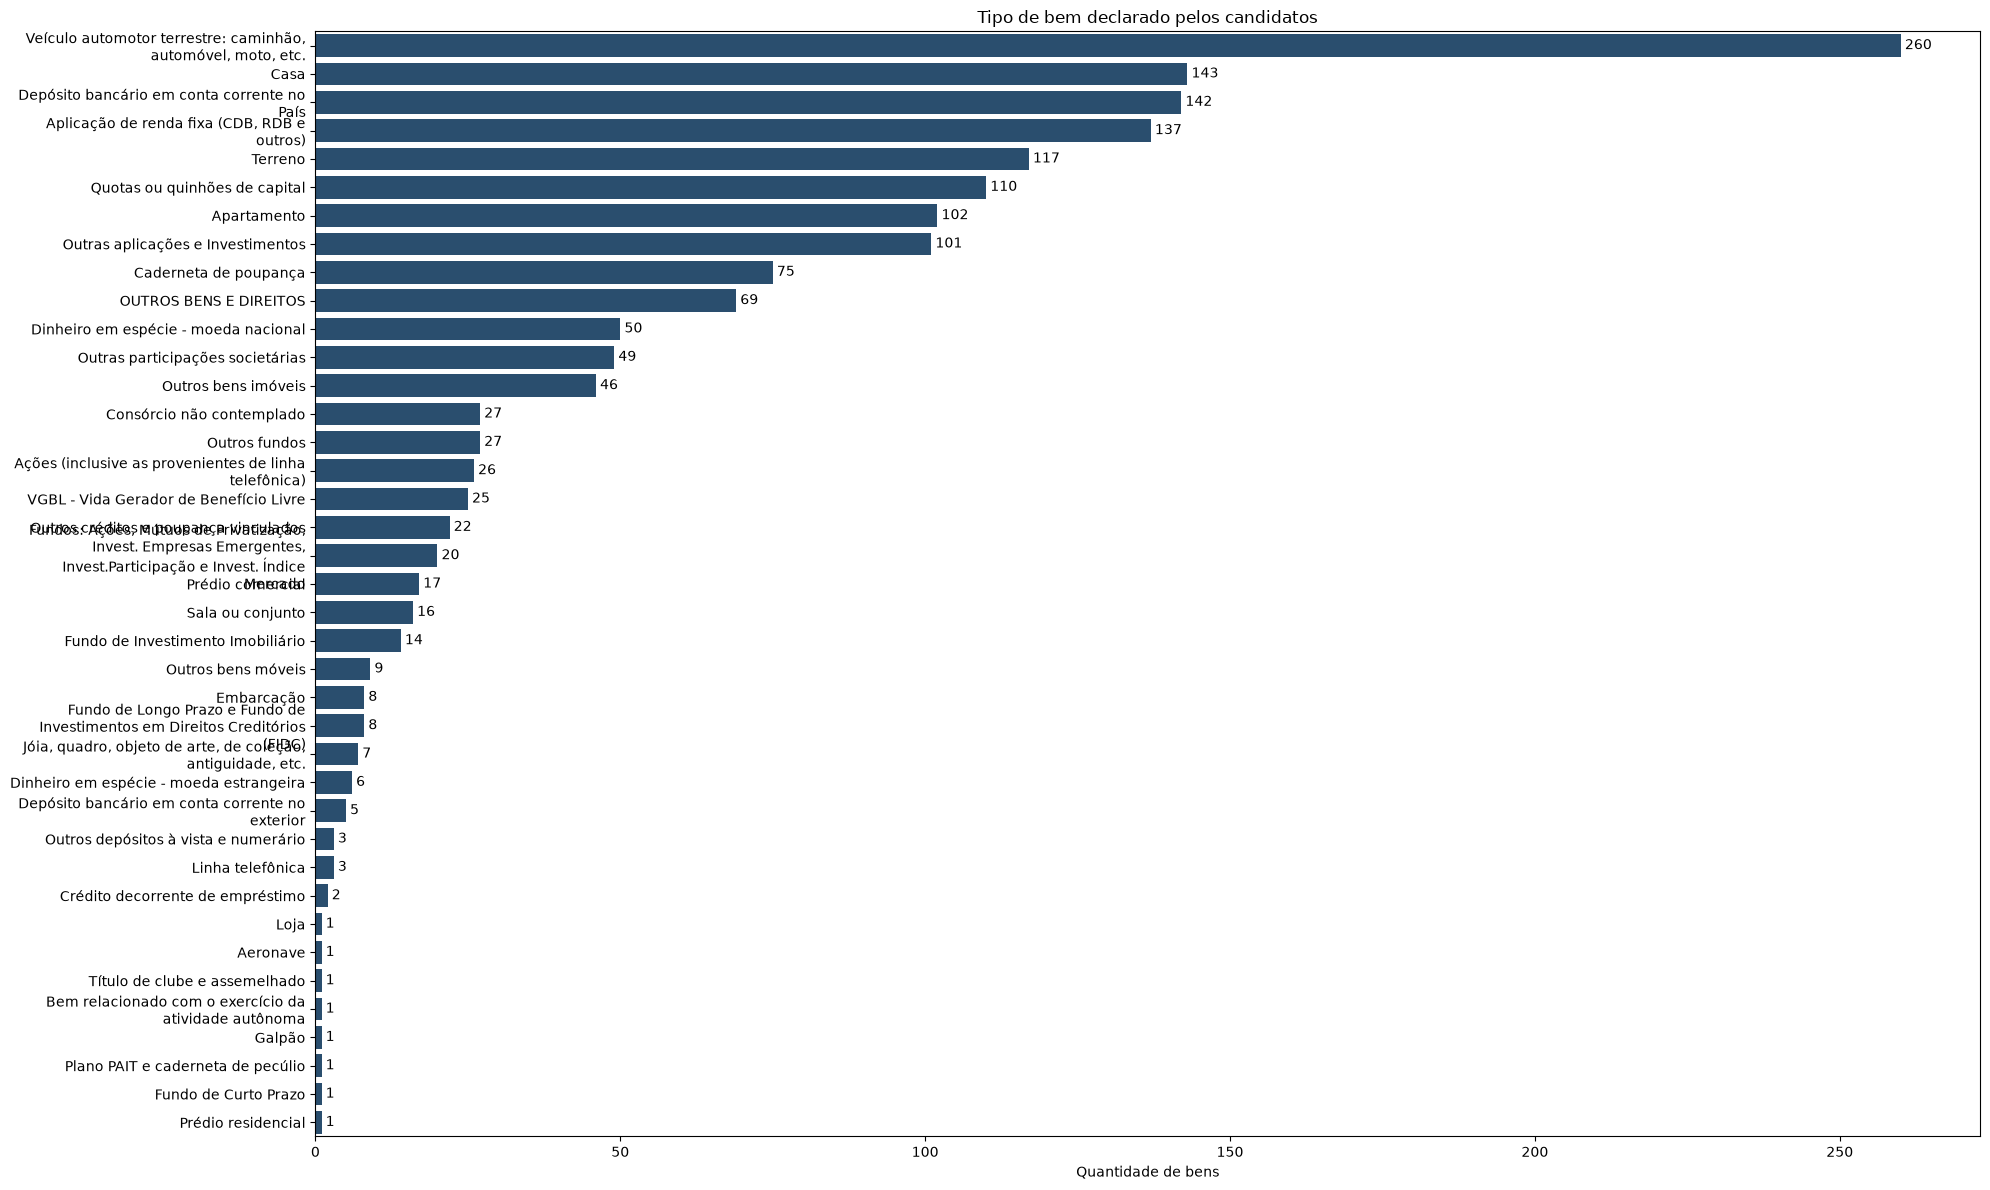

In [12]:
import textwrap

fig, ax = plt.subplots(figsize=(20, 12))

ordem = bens["DS_TIPO_BEM_CANDIDATO"].value_counts().index
sns.countplot(data=bens, y="DS_TIPO_BEM_CANDIDATO",
              order=ordem, ax=ax, color="#1f4e79")

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

posicoes = ax.get_yticks()
rótulos = [textwrap.fill(label.get_text(), width=42)
           for label in ax.get_yticklabels()]
ax.set_yticks(posicoes, rótulos, fontsize=10)
ax.set_title("Tipo de bem declarado pelos candidatos")
ax.set_xlabel("Quantidade de bens")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Análise do histograma

O histograma de `VR_TOTAL_BENS` mostra uma distribuição fortemente assimétrica à direita, com grande concentração de candidatos com patrimônio baixo ou nulo e uma cauda longa formada por poucos candidatos com valores muito elevados. Isso indica que a maior parte dos candidatos declarou bens em faixas mais baixas, enquanto poucos casos extremos puxam a escala para cima.

Essa forma de distribuição é comum em variáveis financeiras, porque os valores tendem a se concentrar em poucos intervalos e alguns candidatos acumulam patrimônio bem acima da média. Por isso, a média sozinha não representa bem o conjunto; a mediana e os quartis descrevem melhor o comportamento central dos dados.


In [13]:
def n_bins(serie):
    s = serie.dropna().to_numpy()
    n = len(s)
    k_sturges = int(np.ceil(np.log2(n)) + 1)
    iqr = np.subtract(*np.percentile(s, [75, 25]))
    h_fd = 2 * iqr / np.cbrt(n)
    k_fd = int(np.ceil((s.max() - s.min()) / h_fd))
    return k_sturges, k_fd


ks_vr_bem, kfd_vr_bem = n_bins(bens_por_candidato["patrimonio_total"])
print(
    f"patrimonio_total  (n={bens_por_candidato['patrimonio_total'].dropna().shape[0]:,})   Sturges = {ks_vr_bem:>3}   Freedman-Diaconis = {kfd_vr_bem:>3}")

patrimonio_total  (n=468)   Sturges =  10   Freedman-Diaconis = 704


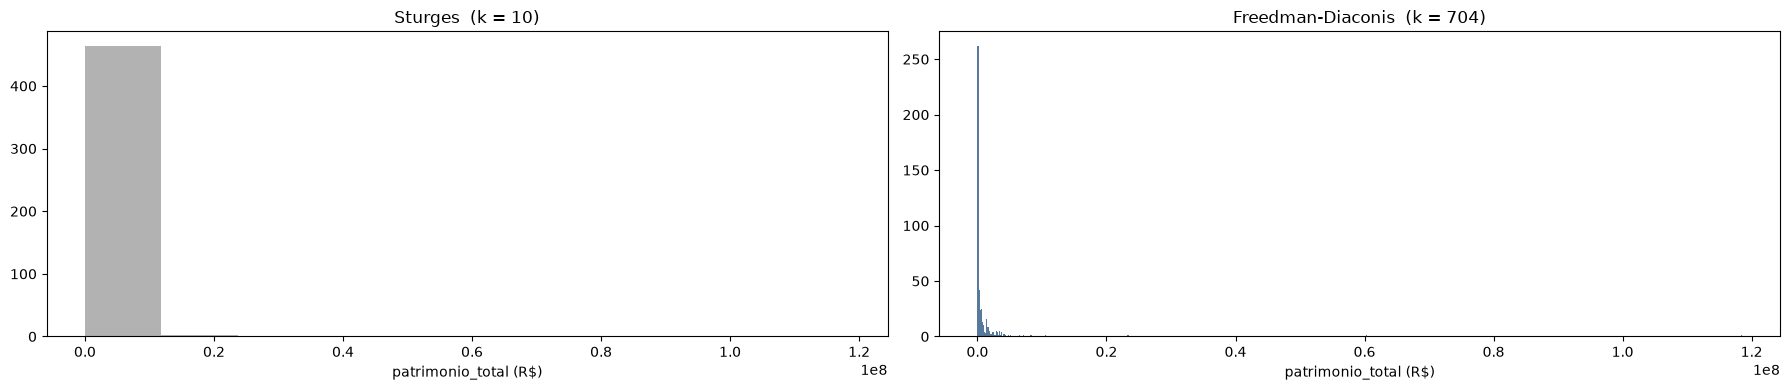

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

vr_bem = bens_por_candidato['patrimonio_total'].dropna()
sns.histplot(vr_bem, bins=ks_vr_bem,
             ax=axes[0], color="#999999", edgecolor="none")
axes[0].set_title(f"Sturges  (k = {ks_vr_bem})")
sns.histplot(vr_bem, bins=kfd_vr_bem,
             ax=axes[1], color="#1f4e79", edgecolor="none")
axes[1].set_title(f"Freedman-Diaconis  (k = {kfd_vr_bem})")
for ax in axes:
    ax.set_xlabel("patrimonio_total (R$)")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Análise do boxplot

O boxplot confirma o padrão observado no histograma: os valores de `VR_TOTAL_BENS` estão concentrados nas faixas mais baixas, com forte assimetria à direita e presença de valores extremos. A mediana fica próxima da parte inferior da caixa, o que reforça que a maioria dos candidatos possui patrimônio relativamente baixo em relação aos maiores valores observados.

O intervalo interquartil é amplo, mas os limites de Tukey indicam que há observações muito distantes do centro da distribuição. Como os dados não podem ser negativos, o whisker inferior fica em `0,00`, enquanto o superior se estende bastante, evidenciando a presença de candidatos com patrimônio muito acima do padrão geral. Em resumo, o boxplot mostra uma distribuição heterogênea e com forte influência de outliers no lado superior.


IQR = 654066.58 R$
Limites de Tukey  : [-981099.87 ; 1635166.45]
Whiskers de fato  : [0.00 ; 1614067.13]


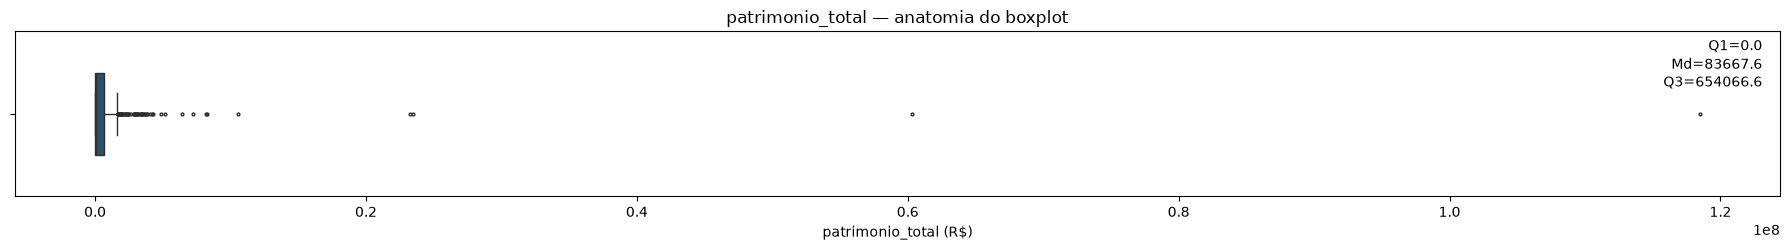

In [15]:
fig, ax = plt.subplots(figsize=(18, 2.6))
vr_total_bens = bens_por_candidato["patrimonio_total"].dropna()
sns.boxplot(x=vr_total_bens, ax=ax, color="#1f4e79", width=0.5, fliersize=2)

q1, q2, q3 = vr_total_bens.quantile([.25, .50, .75])
iqr = q3 - q1

ax.text(0.99, 0.95, f"Q1={q1:.1f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=10)
ax.text(0.99, 0.84, f"Md={q2:.1f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=10)
ax.text(0.99, 0.73, f"Q3={q3:.1f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=10)

ax.set_title("patrimonio_total — anatomia do boxplot")
ax.set_xlabel("patrimonio_total (R$)")
print(f"IQR = {iqr:.2f} R$")
print(f"Limites de Tukey  : [{q1 - 1.5*iqr:.2f} ; {q3 + 1.5*iqr:.2f}]")
print(f"Whiskers de fato  : [{vr_total_bens[vr_total_bens >= q1 - 1.5*iqr].min():.2f} ; "
      f"{vr_total_bens[vr_total_bens <= q3 + 1.5*iqr].max():.2f}]")
plt.tight_layout()
plt.show()

### Interpretação das estatísticas descritivas

Os valores de `VR_BEM_CANDIDATO` mostram uma assimetria forte à direita: a média fica em torno de R$ 310,7 mil, enquanto a mediana é de R$ 65 mil, bem menor. Essa diferença indica que alguns valores muito altos estão puxando a média para cima, o que é reforçado pelo desvio padrão elevado, de cerca de R$ 2,41 milhões, mostrando grande dispersão e presença de outliers.

O intervalo interquartil vai de R$ 10 mil a R$ 225 mil, então os 50% centrais dos registros estão concentrados em uma faixa relativamente modesta quando comparada ao máximo observado, de mais de R$ 92 milhões. A moda também tende a se concentrar nos valores mais baixos, o que sugere que a maior parte dos candidatos declara bens de menor valor, mas uma pequena parcela concentra patrimônios muito superiores. Em resumo, a diferença entre média, mediana e desvio padrão revela uma distribuição heterogênea, não simétrica e fortemente influenciada por poucos casos extremos.


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VR_BEM_CANDIDATO,1653.0,310683.207181,2.407897e+06,0.0,10000.0,65000.0,225000.0,92004111.43


### Comparação sobre patrimônio por cargo

A comparação por cargo mostra que os cargos majoritários, como governador e senador, concentram os maiores patrimônios medianos, o que sugere a presença de candidatos com perfil econômico mais elevado nessas disputas. Já cargos com maior quantidade de candidatos, como deputado estadual e deputado federal, apresentam patrimônio total expressivo, mas isso ocorre principalmente pelo volume de participantes, não necessariamente por terem os maiores valores individuais.

Por isso, a mediana é a medida mais adequada para interpretar esse recorte, porque reduz o efeito de valores extremos. Em síntese, o padrão observado indica forte desigualdade patrimonial entre cargos: alguns concentram candidatos com patrimônio muito alto, enquanto outros reúnem perfis mais heterogêneos e com valores centrais menores.


,DS_CARGO,quantidade_candidatos,patrimonio_medio,patrimonio_mediano,patrimonio_total
4,GOVERNADOR,7,1.830148e+07,1657000.00,1.281104e+08
6,VICE-GOVERNADOR,7,5.725595e+05,436929.13,4.007917e+06
5,SENADOR,9,7.268644e+06,300000.00,6.541779e+07
0,1º SUPLENTE,9,3.627226e+06,150000.00,3.264503e+07
2,DEPUTADO ESTADUAL,289,7.230239e+05,100000.00,2.089539e+08
1,2º SUPLENTE,9,4.811893e+05,85577.57,4.330703e+06
3,DEPUTADO FEDERAL,138,5.079248e+05,47231.27,7.009363e+07


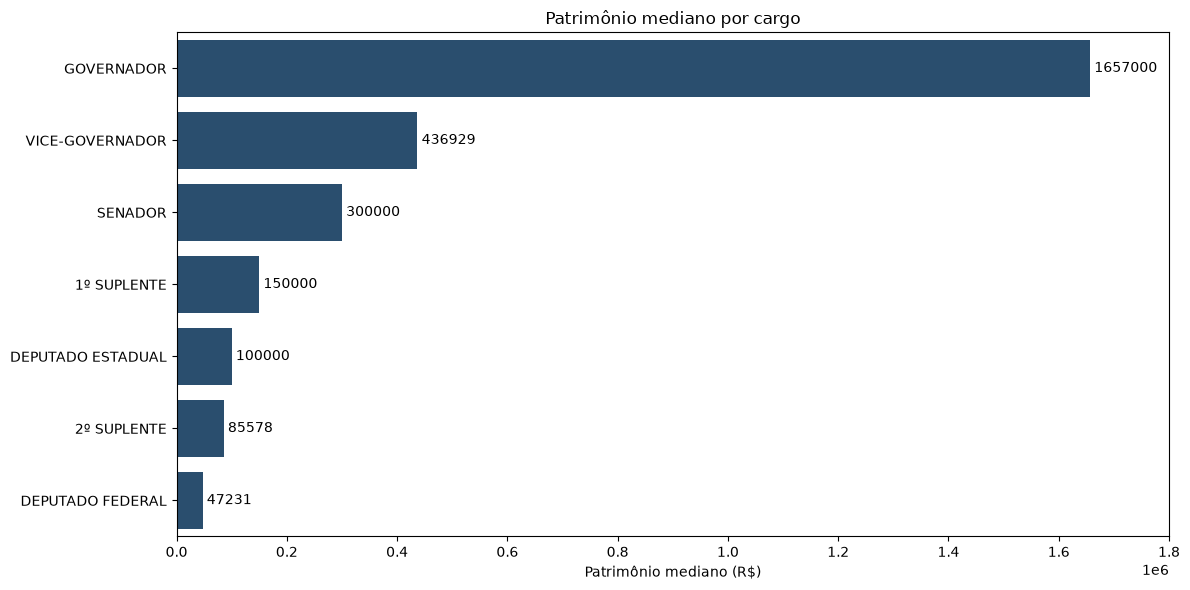

In [17]:
# Comparação de patrimônio por cargo usando o dataframe bens_por_candidato
resumo_por_cargo = (
    bens_por_candidato.groupby("DS_CARGO", as_index=False)
    .agg(quantidade_candidatos=("SQ_CANDIDATO", "count"),
         patrimonio_medio=("patrimonio_total", "mean"),
         patrimonio_mediano=("patrimonio_total", "median"),
         patrimonio_total=("patrimonio_total", "sum"))
)

resumo_por_cargo = resumo_por_cargo.sort_values(
    "patrimonio_mediano", ascending=False)
display(resumo_por_cargo)

top_cargos = resumo_por_cargo.head(8)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=top_cargos,
    x="patrimonio_mediano",
    y="DS_CARGO",
    ax=ax,
    color="#1f4e79"
)

ax.set_title("Patrimônio mediano por cargo")
ax.set_xlabel("Patrimônio mediano (R$)")
ax.set_ylabel("")
ax.set_xlim(0, 1_800_000)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

### Comparação sobre patrimônio por partido

A comparação por partido mostra uma distribuição patrimonial bastante desigual entre as siglas. Partidos como PP, MDB, PSDB e UNIÃO aparecem com maiores patrimônios medianos, o que indica a presença de candidatos com perfil econômico mais elevado nesses grupos. Ao mesmo tempo, partidos com grande quantidade de candidatos, como PL e PSD, também concentram valores totais altos, mas isso se deve mais ao volume de participantes do que ao patrimônio individual mediano.

Esse resultado reforça a importância de usar a mediana como referência principal, porque ela reduz o impacto de candidatos com patrimônio muito alto e representa melhor o comportamento típico de cada partido. Em síntese, o recorte por partido evidencia diferenças relevantes de perfil patrimonial entre as legendas, mas a interpretação deve considerar sempre tanto o tamanho da amostra quanto a presença de valores extremos.


,SG_PARTIDO,quantidade_candidatos,patrimonio_medio,patrimonio_mediano,patrimonio_total
11,PP,6,1.588027e+06,1624053.665,9.528163e+06
3,MDB,36,3.102824e+06,674338.480,1.117017e+08
14,PSDB,3,1.437696e+06,635956.260,4.313089e+06
21,UNIÃO,33,1.374139e+06,554943.250,4.534660e+07
1,AVANTE,34,8.934261e+05,552082.590,3.037649e+07
9,PL,39,4.548349e+06,342867.000,1.773856e+08
13,PSD,36,1.375057e+06,279953.195,4.950206e+07
0,AGIR,25,7.019318e+05,250000.000,1.754829e+07
17,PT,21,4.923387e+05,106572.110,1.033911e+07
6,NOVO,34,1.846471e+05,27500.000,6.278000e+06


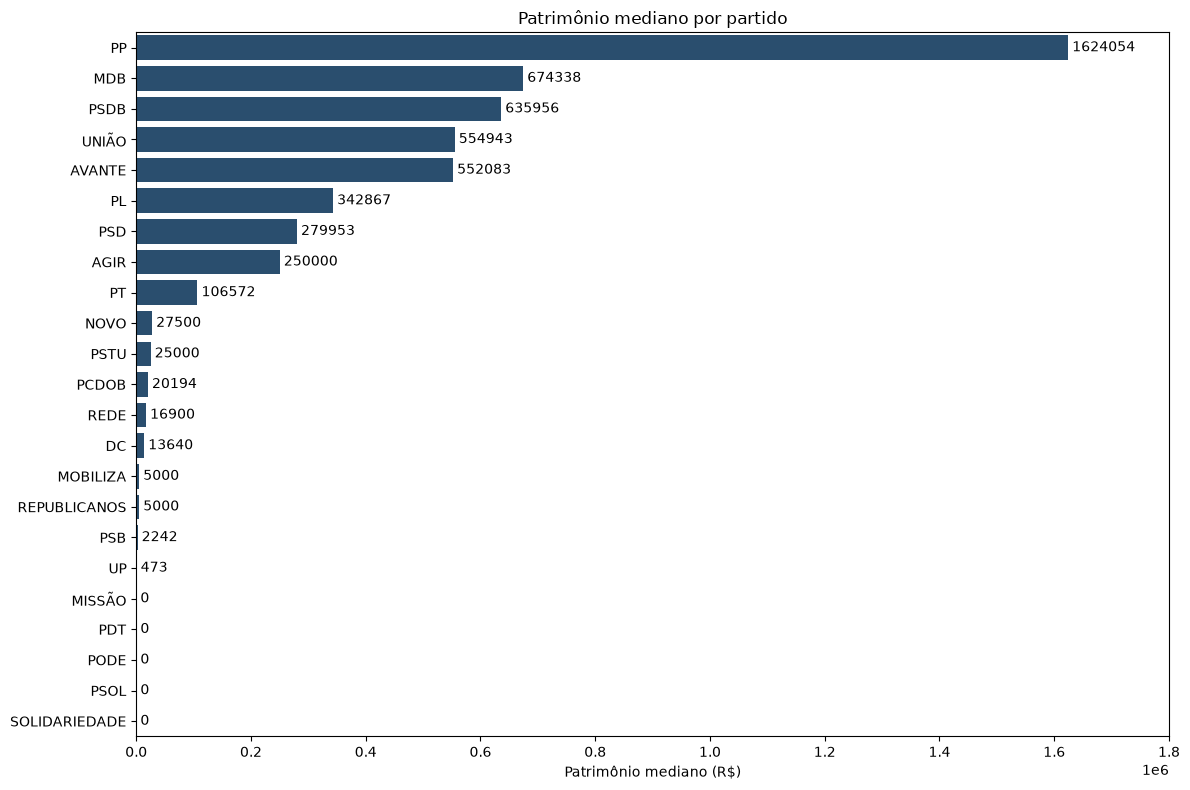

In [18]:
# Comparação de patrimônio por partido usando o dataframe bens_por_candidato
resumo_por_partido = (
    bens_por_candidato.groupby("SG_PARTIDO", as_index=False)
    .agg(quantidade_candidatos=("SQ_CANDIDATO", "count"),
         patrimonio_medio=("patrimonio_total", "mean"),
         patrimonio_mediano=("patrimonio_total", "median"),
         patrimonio_total=("patrimonio_total", "sum"))
)

resumo_por_partido = resumo_por_partido.sort_values(
    "patrimonio_mediano", ascending=False)
display(resumo_por_partido)

top_partidos = resumo_por_partido.head(23)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    data=top_partidos,
    x="patrimonio_mediano",
    y="SG_PARTIDO",
    ax=ax,
    color="#1f4e79"
)

ax.set_title("Patrimônio mediano por partido")
ax.set_xlabel("Patrimônio mediano (R$)")
ax.set_ylabel("")
ax.set_xlim(0, 1_800_000)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

### Narrativa (storytelling)

**Contexto.** O join entre o cadastro de candidatos e a base de bens permite observar não apenas quanto cada candidato declarou, mas também como esse patrimônio se distribui entre cargos e partidos no Amazonas. Em vez de olhar só para valores individuais, o cruzamento ajuda a identificar padrões de concentração patrimonial dentro dos grupos políticos.

**Conflito / insight.** Os números mostram uma desigualdade forte entre os cargos: a mediana de patrimônio entre governadores foi de R\$ 1.657.000, enquanto entre senadores ficou em R\$ 300.000, entre deputados estaduais em R\$ 100.000 e entre deputados federais em R\$ 47.231. Isso indica que o patrimônio declarado não se distribui de forma homogênea; ele se concentra nos cargos mais altos da disputa. Analisando por partido, o padrão também aparece: o PP teve mediana de R\$ 1.624.054, muito acima de siglas como PSOL, PDT, PODE e SOLIDARIEDADE, cujas medianas ficaram em R\$ 0 não possuíam ou simplesmente não declararam patromônio, o que é bastante estranho dada a realidade de privilégios da classe política no Brasil.

**Conclusão.** Em resumo, se pudermos acreditar na veracidade das informações declaradas pelos candidatos, este conjunto de dados mostra que os candidatos do AM formam um grupo patrimonialmente heterogêneo, com forte concentração de riqueza em poucos cargos e em algumas legendas. O join evidencia que a disputa majoritária reúne os perfis mais ricos, enquanto a maioria dos demais grupos concentra patrimônios bem menores ou inexistentes, reforçando uma assimetria importante dentro da eleição.


In [19]:
# Salvando o DataFrame limpo em um novo arquivo CSV
bens_por_candidato.to_csv('bens_am_por_candidato.csv', index=False)

print("Arquivo 'bens_am_por_candidato.csv' salvo com sucesso!")

Arquivo 'bens_am_por_candidato.csv' salvo com sucesso!
